# 🛡️ DeepShield: EDA, Visualisasi, dan Explanatory Analysis

## Coding Camp 2026 | Capstone Project

---
Notebook ini merupakan **analisis eksplorasi** terhadap dataset gambar wajah *Fake* dan *Real* yang dikumpulkan pada tahun **2020-2026**. Tujuan utamanya adalah memahami kondisi data dari sisi **jumlah gambar**, **karakteristik piksel**, dan **distribusi warna** sebelum data tersebut digunakan untuk pemodelan lebih lanjut.
 
Setiap bagian analisis dibuat dengan **bahasa yang mudah dipahami**, mencakup penjelasan metode yang digunakan, alasan pemilihan metode, hasil temuan, dan rekomendasi yang dapat langsung diterapkan. Dataset terdiri dari gambar wajah berformat *JPG* atau *JPEG* yang dibaca secara **dinamis dan otomatis** menggunakan pencarian rekursif (berulang) sehingga notebook tetap berjalan dengan aman meskipun jumlah file atau lokasi folder berubah di masa depan.

---

## 1. Identitas dan Tujuan Analisis


| | |
|---|---|
| **Nama Proyek** | DeepShield: Sistem Deteksi Deepfake untuk Menjaga Kepercayaan Masyarakat di Era Informasi Digital |
| **Tema Capstone** | *Inclusive and Resilient Communities* |
| **Fokus Analisis** | Dataset gambar wajah *Fake* dan *Real* tahun 2020-2026 |
| **Target Pembaca** | Pengguna yang membutuhkan analisis lanjutan dari dataset tersebut |
 
Analisis ini **tidak bertujuan** menentukan bahwa suatu gambar pasti palsu atau asli karena fokusnya adalah memahami **pola umum** dari seluruh dataset seperti apakah data sudah cukup *seimbang*, apakah terdapat perbedaan dalam hal *pencahayaan dan kontras*, serta apakah informasi *warna RGB* menjadi indikator awal untuk membedakan gambar *Fake* dan *Real*.

### Alur notebook

1. Menyiapkan library dan konfigurasi analisis.
2. Membaca seluruh file gambar secara dinamis.
3. Mengubah informasi gambar menjadi tabel fitur yang mudah dianalisis.
4. Melakukan eksplorasi data awal untuk memahami kondisi dataset.
5. Menjawab tiga pertanyaan bisnis utama menggunakan tabel dan visualisasi.
6. Memberikan insight temuan, kesimpulan, dan rekomendasi action items.

---

## 2. Pertanyaan Bisnis & Kerangka SMART

Sebelum melakukan analisis, perlu mendefinisikan terlebih dahulu apa yang ingin diketahui dari dataset tersebut dalam bentuk **Pertanyaan Bisnis (*Business Question* atau BQ)**. Pertanyaan bisnis dibuat menggunakan kerangka **SMART** agar analisis jelas, relevan, dan berdampak.

---

### BQ 1 — Keseimbangan Kelas

> *Bagaimana proporsi kelas antara gambar "Fake" dan "Real" pada dataset Deepfake tahun 2020-2026, dan apakah diperlukan penanganan imbalanced data (seperti SMOTE atau undersampling) sebelum melatih model?*

| Dimensi SMART | Penjelasan |
|---|---|
| **S — Spesifik** | Menghitung jumlah dan persentase gambar untuk kelas `Fake` dan `Real` pada setiap split (*Train*, *Validation*, *Test*) di dataset tahun 2020-2026. |
| **T — Terukur** | Rasio kelas (Fake dan Real), selisih mutlak jumlah sampel, dan persentase ketidakseimbangan dinyatakan dalam angka pasti. Ambang batas: rasio > 1.5:1 dianggap perlu penanganan khusus. |
| **A — Dapat Ditindaklanjuti** | Jika kelas tidak seimbang, perlu menerapkan SMOTE (oversampling) atau *random undersampling* sebelum pelatihan. Jika seimbang, kelas bisa diperlakukan setara tanpa penyesuaian bobot. |
| **R — Relevan** | Ketidakseimbangan kelas yang tidak ditangani dapat membuat model bias dan cenderung memprediksi kelas mayoritas dan mengabaikan minoritas, sehingga akurasi tampak tinggi namun recall-nya buruk. |
| **T — Terikat Waktu** | Analisis ini terbatas pada dataset yang dikumpulkan pada **tahun 2020-2026** sebagai referensi utama proyek. |

---

### BQ 2 — Distribusi Kecerahan & Kontras

> *Bagaimana perbedaan distribusi tingkat pencahayaan (brightness) dan kontras (contrast) antara gambar "Fake" dan "Real" pada dataset tahun 2020-2026, dan apakah perbedaan tersebut memerlukan penerapan teknik augmentasi/manipulasi data gambar (seperti color jittering) selama pelatihan model?*

| Dimensi SMART | Penjelasan |
|---|---|
| **S — Spesifik** | Membandingkan nilai rata-rata kecerahan grayscale (`brightness_mean`) dan standar deviasi grayscale dengan nilai standar deviasi grayscale sebagai nilai estimasi standar deviasi kontras (`contrast_std`) antara kelas `Fake` dan `Real`. |
| **T — Terukur** | Perbedaan dievaluasi secara statistik menggunakan uji Mann-Whitney U (p-value) dan ukuran efek Cohen's d. Jika nilai efek d > 0.5, maka dianggap signifikan secara praktis. |
| **A — Dapat Ditindaklanjuti** | Jika distribusi keduanya berbeda secara signifikan, perlu menerapkan augmentasi *color jittering* (brightness, contrast) agar model tidak belajar dari artefak pencahayaan yang bias terhadap kelas tertentu. |
| **R — Relevan** | Perbedaan sistematis pada pencahayaan dan kontras bisa menjadi "jalan pintas" yang dipelajari model bukan karena perbedaan wajah asli vs palsu, melainkan karena perbedaan kondisi pencahayaan. Ini menciptakan model yang bias dan tidak reliabilitas di data real lainnya. |
| **T — Terikat Waktu** | Analisis berfokus pada data tahun 2020-2026; kondisi distribusi mungkin berbeda pada dataset tahun lain. |

---

### BQ 3 — Anomali Distribusi Channel RGB

> *Apakah terdapat anomali atau pergeseran distribusi nilai intensitas warna pada channel RGB (Red, Green, Blue) gambar "Fake" dibandingkan "Real" di dataset tahun 2020-2026, yang dapat dimanfaatkan untuk menentukan arsitektur layer (seperti Channel Attention) pada model pendeteksi?*

| Dimensi SMART | Penjelasan |
|---|---|
| **S — Spesifik** | Membandingkan distribusi nilai rata-rata channel R, G, dan B (`r_mean`, `g_mean`, `b_mean`) antara kelas `Fake` dan `Real`, serta mengidentifikasi channel mana yang menunjukkan perbedaan distribusi terbesar. |
| **T — Terukur** | Perbedaan dievaluasi dengan KDE overlay, box plot, dan Cohen's d per channel. Channel dengan nlai absolut d > 0.2 dianggap memiliki sinyal yang relevan untuk digunakan model. |
| **A — Dapat Ditindaklanjuti** | Jika ada channel yang menunjukkan pergeseran distribusi konsisten, maka dapat mempertimbangkan penggunaan arsitektur **Channel Attention** (seperti SE-Net atau CBAM) untuk memberi bobot lebih pada channel yang paling informatif. |
| **R — Relevan** | Proses pembuatan wajah deepfake sering meninggalkan jejak artefak (buatan komputer) pada channel warna tertentu, terutama pada area kulit wajah. Mengidentifikasi channel informatif bisa menjadi keunggulan arsitektur model. |
| **T — Terikat Waktu** | Analisis berfokus pada data tahun 2020-2026; pola artefak GAN bisa berbeda seiring evolusi teknologi deepfake. |


In [1]:
# ================================================================
# 1. IMPORT LIBRARY DAN KONFIGURASI AWAL
# ================================================================

from pathlib import Path
from concurrent.futures import ThreadPoolExecutor
import hashlib
import math
import os
import random
import warnings

import numpy as np
import pandas as pd

from PIL import Image, ImageFile, UnidentifiedImageError
ImageFile.LOAD_TRUNCATED_IMAGES = True

import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown
from tqdm.auto import tqdm

try:
    from scipy import stats as scipy_stats
    SCIPY_AVAILABLE = True
except ImportError:
    SCIPY_AVAILABLE = False

warnings.filterwarnings("ignore")

DATASET_YEAR = "2020-2026"
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}
CLASS_ALIASES = {"fake": "Fake", "real": "Real"}
CLASS_ORDER = ["Fake", "Real"]
SPLIT_ORDER = ["Train", "Validation", "Test"]
SPLIT_ALIASES = {
    "train": "Train",
    "training": "Train",
    "validation": "Validation",
    "valid": "Validation",
    "val": "Validation",
    "test": "Test",
}

FEATURE_THUMB_SIZE = (128, 128)
PLOT_SAMPLE_SIZE = 12000
RGB_SAMPLE_SIZE = 15000
RANDOM_STATE = 42
N_WORKERS = min(os.cpu_count() or 4, 8)
FORCE_RECOMPUTE = False

random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

REAL_COLOR = "#38AFCF"
FAKE_COLOR = "#C84BCB"
DEEPSHIELD_PALETTE = {"Fake": FAKE_COLOR, "Real": REAL_COLOR}
PALETTE_LIST = [DEEPSHIELD_PALETTE[c] for c in CLASS_ORDER]

if Path("/kaggle/working").exists():
    BASE_OUT = Path("/kaggle/working/deepshield_eda_outputs")
else:
    BASE_OUT = Path("./deepshield_eda_outputs")

TABLE_DIR = BASE_OUT / "tables"
FIG_DIR = BASE_OUT / "figures"
for directory in [BASE_OUT, TABLE_DIR, FIG_DIR]:
    directory.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
sns.set_palette(PALETTE_LIST)
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 130,
    "axes.titlesize": 14,
    "axes.labelsize": 11,
    "font.family": "sans-serif",
})

pd.set_option("display.max_columns", 40)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

print("Setup selesai.")
print(f"Tahun dataset: {DATASET_YEAR}")
print(f"Direktori output: {BASE_OUT.resolve()}")
print(f"SciPy tersedia: {SCIPY_AVAILABLE}")
print(f"Jumlah worker: {N_WORKERS}")

Setup selesai.
Tahun dataset: 2020-2026
Direktori output: /kaggle/working/deepshield_eda_outputs
SciPy tersedia: True
Jumlah worker: 4


## 3. Membaca Dataset Gambar Secara Dinamis

---

Notebook membaca seluruh file gambar secara **otomatis** menggunakan metode **pencarian rekursif** (`pathlib.Path.rglob`), tanpa perlu menulis setiap path folder secara manual. Setiap file yang ditemukan kemudian diidentifikasi **kelas** (Fake/Real) dan **split**-nya (Train/Validation/Test) berdasarkan nama folder dalam path. Pendekatan **dinamis** ini memastikan notebook tetap berjalan dengan aman meskipun jumlah gambar bertambah, lokasi folder berubah, atau notebook dijalankan di lingkungan Kaggle ataupun lokal.

---

In [2]:
# ================================================================
# 2. HELPER FUNCTION UNTUK MEMBACA DATA DAN MENGHITUNG STATISTIK
# ================================================================

def normalize_text(value: str) -> str:
    return str(value).strip().lower().replace(" ", "").replace("_", "")


def percentage(part, total) -> float:
    if total == 0 or pd.isna(total):
        return 0.0
    return float(part) / float(total) * 100.0


def safe_sample(df: pd.DataFrame, n: int, random_state: int = RANDOM_STATE) -> pd.DataFrame:
    if len(df) <= n:
        return df.copy()
    return df.sample(n=n, random_state=random_state).copy()


def cohen_d(group_a, group_b) -> float:
    a = pd.Series(group_a).dropna().astype(float)
    b = pd.Series(group_b).dropna().astype(float)
    if len(a) < 2 or len(b) < 2:
        return np.nan
    pooled_var = ((len(a) - 1) * a.var(ddof=1) + (len(b) - 1) * b.var(ddof=1)) / (len(a) + len(b) - 2)
    pooled_std = math.sqrt(pooled_var) if pooled_var > 0 else 0
    return (a.mean() - b.mean()) / pooled_std if pooled_std else 0.0


def effect_size_label(value: float) -> str:
    if pd.isna(value):
        return "Tidak cukup data"
    absolute_value = abs(value)
    if absolute_value < 0.2:
        return "Sangat kecil"
    if absolute_value < 0.5:
        return "Kecil"
    if absolute_value < 0.8:
        return "Sedang"
    return "Besar"


def mann_whitney_result(group_a, group_b) -> dict:
    if not SCIPY_AVAILABLE:
        return {
            "statistic": np.nan,
            "p_value": np.nan,
            "significance": "SciPy tidak tersedia",
        }
    a = pd.Series(group_a).dropna().astype(float).values
    b = pd.Series(group_b).dropna().astype(float).values
    if len(a) == 0 or len(b) == 0:
        return {
            "statistic": np.nan,
            "p_value": np.nan,
            "significance": "Data tidak cukup",
        }
    statistic, p_value = scipy_stats.mannwhitneyu(a, b, alternative="two-sided")
    significance = "Signifikan pada p < 0.05" if p_value < 0.05 else "Tidak signifikan pada p < 0.05"
    return {
        "statistic": statistic,
        "p_value": p_value,
        "significance": significance,
    }


def save_figure(filename: str, dpi: int = 150) -> Path:
    path = FIG_DIR / filename
    plt.tight_layout()
    plt.savefig(path, dpi=dpi, bbox_inches="tight")
    print(f"Gambar tersimpan: {path.name}")
    return path


def find_dataset_root() -> Path:
    override = os.environ.get("DEEPSHIELD_DATASET_ROOT", "").strip()
    candidates = []
    if override:
        candidates.append(Path(override))
    candidates.extend([
        Path("/kaggle/input/datasets/petertaniwan/clean-dataset-fake-vs-real"),
        Path("/kaggle/input/clean-dataset-fake-vs-real"),
        Path("/kaggle/input"),
        Path("/mnt/data"),
        Path("."),
    ])

    for root in candidates:
        if not root.exists():
            continue
        for image_path in root.rglob("*"):
            if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            parts = image_path.parts
            normalized_parts = [normalize_text(part) for part in parts]
            for idx, part in enumerate(normalized_parts):
                if part in CLASS_ALIASES:
                    previous_part = normalized_parts[idx - 1] if idx > 0 else ""
                    if previous_part in SPLIT_ALIASES:
                        return Path(*parts[:idx - 1])
                    return Path(*parts[:idx])
    raise FileNotFoundError(
        "Dataset tidak ditemukan. Pastikan dataset sudah ditambahkan ke Kaggle Input atau isi environment variable DEEPSHIELD_DATASET_ROOT."
    )


def infer_split_and_class(image_path: Path, dataset_root: Path) -> tuple:
    relative_parts = image_path.relative_to(dataset_root).parts
    normalized_parts = [normalize_text(part) for part in relative_parts]

    class_label = "Unknown"
    class_index = None
    for idx, part in enumerate(normalized_parts):
        if part in CLASS_ALIASES:
            class_label = CLASS_ALIASES[part]
            class_index = idx
            break

    split_label = "Unknown"
    if class_index is not None and class_index > 0:
        previous_part = normalized_parts[class_index - 1]
        split_label = SPLIT_ALIASES.get(previous_part, relative_parts[class_index - 1])

    return split_label, class_label

print("Helper function siap digunakan.")

Helper function siap digunakan.


In [3]:
# ================================================================
# 3. DETEKSI DATASET DAN INVENTARISASI FILE GAMBAR
# ================================================================

dataset_root = find_dataset_root()
print(f"Dataset root: {dataset_root}")

records = []
for image_path in sorted(dataset_root.rglob("*")):
    if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
        continue
    split_label, class_label = infer_split_and_class(image_path, dataset_root)
    records.append({
        "split": split_label,
        "class": class_label,
        "file_name": image_path.name,
        "file_path": str(image_path),
        "file_size_kb": image_path.stat().st_size / 1024,
        "extension": image_path.suffix.lower(),
    })

if not records:
    raise ValueError("Tidak ada file gambar JPG atau JPEG yang ditemukan dalam dataset.")

inventory_df = pd.DataFrame(records)
inventory_df = inventory_df[inventory_df["class"].isin(CLASS_ORDER)].copy()

if inventory_df.empty:
    raise ValueError("Gambar ditemukan, tetapi folder kelas Fake dan Real tidak dapat dikenali dari path file.")

inventory_df["class"] = pd.Categorical(inventory_df["class"], categories=CLASS_ORDER, ordered=True)

split_values = [split for split in SPLIT_ORDER if split in inventory_df["split"].unique()]
other_splits = sorted([split for split in inventory_df["split"].dropna().unique() if split not in split_values])
ordered_splits = split_values + other_splits
inventory_df["split"] = pd.Categorical(inventory_df["split"], categories=ordered_splits, ordered=True)

inventory_csv = TABLE_DIR / "image_inventory.csv"
inventory_df.to_csv(inventory_csv, index=False)

print(f"Total file gambar terbaca: {len(inventory_df):,}")
print(f"Inventory tersimpan: {inventory_csv}")

Dataset root: /kaggle/input/datasets/petertaniwan/deepfake-clean-final
Total file gambar terbaca: 371,076
Inventory tersimpan: /kaggle/working/deepshield_eda_outputs/tables/image_inventory.csv


Dataset berhasil dibaca secara dinamis dengan total file terdeteksi pada tiga split (Train, Validation, Test) dan dua kelas (Fake, Real) sehingga siap untuk tahap ekstraksi fitur berikutnya.

## 4. Ekstraksi Fitur Piksel

---

Gambar digital tidak dapat langsung dianalisis seperti data tabular biasa. Oleh karena itu, setiap gambar dikonversi menjadi **representasi numerik** yang merangkum karakteristik visualnya: **brightness** (rata-rata piksel grayscale), **contrast** (standar deviasi piksel grayscale), dan **rata-rata channel RGB** (Red, Green, Blue). Semakin tinggi nilai brightness, semakin terang gambarnya; semakin besar nilai contrast, semakin kuat perbedaan area terang dan gelap dalam satu gambar.

Untuk efisiensi proses, setiap gambar diperkecil menjadi **thumbnail 128×128 piksel** sebelum perhitungan dilakukan. Ukuran asli tetap dicatat dalam kolom `width` dan `height`. Proses ini **tidak mengubah dataset asli** dan notebook hanya membuat tabel ringkasan fitur agar seluruh gambar dapat dianalisis secara statistik.

---

In [4]:
# ================================================================
# 4. EKSTRAKSI FITUR PIKSEL GAMBAR
# ================================================================

def image_hash_short(file_path: str, max_bytes: int = 2048) -> str:
    hasher = hashlib.md5()
    with open(file_path, "rb") as file:
        hasher.update(file.read(max_bytes))
    return hasher.hexdigest()


def extract_image_features(record: dict) -> dict:
    result = {
        **record,
        "width": np.nan,
        "height": np.nan,
        "aspect_ratio": np.nan,
        "megapixels": np.nan,
        "brightness_mean": np.nan,
        "brightness_median": np.nan,
        "contrast_std": np.nan,
        "r_mean": np.nan,
        "g_mean": np.nan,
        "b_mean": np.nan,
        "r_std": np.nan,
        "g_std": np.nan,
        "b_std": np.nan,
        "image_hash": None,
        "is_corrupt": False,
        "error_message": None,
    }

    file_path = record["file_path"]
    try:
        with Image.open(file_path) as image:
            image = image.convert("RGB")
            original_width, original_height = image.size
            result["width"] = int(original_width)
            result["height"] = int(original_height)
            result["aspect_ratio"] = original_width / original_height if original_height else np.nan
            result["megapixels"] = (original_width * original_height) / 1_000_000
            result["image_hash"] = image_hash_short(file_path)

            image.thumbnail(FEATURE_THUMB_SIZE)
            array_rgb = np.asarray(image, dtype=np.float32)
            gray = (
                0.299 * array_rgb[:, :, 0]
                + 0.587 * array_rgb[:, :, 1]
                + 0.114 * array_rgb[:, :, 2]
            )

            result["brightness_mean"] = float(np.mean(gray))
            result["brightness_median"] = float(np.median(gray))
            result["contrast_std"] = float(np.std(gray))
            result["r_mean"] = float(np.mean(array_rgb[:, :, 0]))
            result["g_mean"] = float(np.mean(array_rgb[:, :, 1]))
            result["b_mean"] = float(np.mean(array_rgb[:, :, 2]))
            result["r_std"] = float(np.std(array_rgb[:, :, 0]))
            result["g_std"] = float(np.std(array_rgb[:, :, 1]))
            result["b_std"] = float(np.std(array_rgb[:, :, 2]))

    except (UnidentifiedImageError, OSError, ValueError) as exc:
        result["is_corrupt"] = True
        result["error_message"] = str(exc)[:200]
    except Exception as exc:
        result["is_corrupt"] = True
        result["error_message"] = f"Unexpected error: {str(exc)[:200]}"

    return result

features_csv = TABLE_DIR / "image_features.csv"

if features_csv.exists() and not FORCE_RECOMPUTE:
    image_df = pd.read_csv(features_csv)
    print(f"Fitur gambar dibaca dari cache: {features_csv}")
else:
    records_list = inventory_df.to_dict("records")
    print(f"Mulai ekstraksi fitur untuk {len(records_list):,} gambar.")
    print("Proses ini dapat memakan waktu karena notebook membaca gambar satu per satu.")

    with ThreadPoolExecutor(max_workers=N_WORKERS) as executor:
        raw_results = list(tqdm(
            executor.map(extract_image_features, records_list),
            total=len(records_list),
            desc="Ekstraksi fitur gambar",
        ))

    image_df = pd.DataFrame(raw_results)
    image_df.to_csv(features_csv, index=False)
    print(f"Fitur gambar tersimpan: {features_csv}")

image_df["class"] = pd.Categorical(image_df["class"], categories=CLASS_ORDER, ordered=True)
if "split" in image_df.columns:
    split_values = [split for split in SPLIT_ORDER if split in image_df["split"].unique()]
    other_splits = sorted([split for split in image_df["split"].dropna().unique() if split not in split_values])
    image_df["split"] = pd.Categorical(image_df["split"], categories=split_values + other_splits, ordered=True)

clean_df = image_df[image_df["is_corrupt"] == False].copy()

print(f"Total baris fitur: {len(image_df):,}")
print(f"Total gambar tidak terbaca: {int(image_df['is_corrupt'].sum()):,}")
print(f"Total gambar terbaca & siap dianalisis: {len(clean_df):,}")

display(clean_df.head(3))

Mulai ekstraksi fitur untuk 371,076 gambar.
Proses ini dapat memakan waktu karena notebook membaca gambar satu per satu.


Ekstraksi fitur gambar:   0%|          | 0/371076 [00:00<?, ?it/s]

Fitur gambar tersimpan: /kaggle/working/deepshield_eda_outputs/tables/image_features.csv
Total baris fitur: 371,076
Total gambar tidak terbaca: 0
Total gambar terbaca & siap dianalisis: 371,076


,split,class,file_name,file_path,file_size_kb,extension,width,height,aspect_ratio,megapixels,brightness_mean,brightness_median,contrast_std,r_mean,g_mean,b_mean,r_std,g_std,b_std,image_hash,is_corrupt,error_message
0,Test,Fake,0001 (10047).jpg,/kaggle/input/datasets/petertaniwan/deepfake-c...,9.5273,.jpg,205,256,0.8008,0.0525,117.8163,131.7735,77.5306,123.8167,115.8058,112.4308,74.7541,79.1546,80.9179,5b158134ae2dc4a3a6d837c6c73d6fda,False,None
1,Test,Fake,0001 (10065).jpg,/kaggle/input/datasets/petertaniwan/deepfake-c...,11.6328,.jpg,205,256,0.8008,0.0525,73.3034,50.8615,53.8854,92.1774,66.5512,58.5685,69.0897,51.0631,41.0950,d864c8b11c4bf28a43c254fe529f8f9c,False,None
2,Test,Fake,0001 (10067).jpg,/kaggle/input/datasets/petertaniwan/deepfake-c...,12.8818,.jpg,166,256,0.6484,0.0425,117.4482,114.8060,54.3245,132.2085,113.2976,100.1067,66.4496,51.2841,46.6513,56b01edc40df7416ff9514dfc293f789,False,None


Tiga baris pertama tabel fitur menampilkan bahwa setiap gambar berhasil direpresentasikan ke dalam atribut numerik seperti dimensi, brightness, contrast, dan rata-rata channel RGB. Struktur tabel ini memastikan proses ekstraksi berjalan benar dan data siap dianalisis lebih lanjut.

## 5. Eksplorasi Data Awal

---

Sebelum menjawab pertanyaan bisnis, notebook melakukan **eksplorasi data awal** untuk memahami kondisi dasar dataset. Tahap ini mencakup pemeriksaan **struktur tabel**, **kualitas file**, **missing value**,**keseragaman ukuran gambar**, dan **statistik deskriptif**. Pemahaman menyeluruh di tahap ini memastikan bahwa seluruh analisis lanjutan dilakukan dengan data yang valid dan terpercaya.

---

### 5.1 Struktur Data yang Terbaca

---

Notebook menampilkan jumlah baris, jumlah kolom, **tipe data** setiap kolom, dan jumlah nilai non-null. Pemeriksaan ini memastikan bahwa hasil ekstraksi gambar telah berhasil dikonversi menjadi **tabel fitur** yang siap digunakan untuk analisis statistik ataupun visualisasi.

---

In [5]:
# ================================================================
# 5. EKSPLORASI DATA AWAL
# ================================================================

print("Informasi struktur tabel fitur:")
image_df.info()


Informasi struktur tabel fitur:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 371076 entries, 0 to 371075
Data columns (total 22 columns):
 #   Column             Non-Null Count   Dtype   
---  ------             --------------   -----   
 0   split              371076 non-null  category
 1   class              371076 non-null  category
 2   file_name          371076 non-null  object  
 3   file_path          371076 non-null  object  
 4   file_size_kb       371076 non-null  float64 
 5   extension          371076 non-null  object  
 6   width              371076 non-null  int64   
 7   height             371076 non-null  int64   
 8   aspect_ratio       371076 non-null  float64 
 9   megapixels         371076 non-null  float64 
 10  brightness_mean    371076 non-null  float64 
 11  brightness_median  371076 non-null  float64 
 12  contrast_std       371076 non-null  float64 
 13  r_mean             371076 non-null  float64 
 14  g_mean             371076 non-null  float64 
 15  b_

Tabel info menunjukkan 371.076 baris dengan 22 kolom, dengan fitur numerik bertipe int64 atau float64 dan kolom kategorikal bertipe object/Categorical. Tidak ada indikasi tipe data yang tidak sesuai, sehingga data siap digunakan untuk analisis statistik dan visualisasi tanpa memerlukan tahap konversi tipe data tambahan.


### 5.2 Kualitas File Gambar

---

Notebook menghitung jumlah gambar yang **berhasil dibaca** dan jumlah gambar yang **corrupt** (tidak terbaca). Pemeriksaan ini penting karena file yang rusak menghasilkan nilai piksel tidak valid yang berpotensi merusak hasil analisis.

---

In [6]:
quality_summary = pd.DataFrame({
    "metric": [
        "Total gambar diproses",
        "Gambar terbaca normal",
        "Gambar tidak terbaca",
        "Persentase gambar tidak terbaca",
    ],
    "value": [
        len(image_df),
        len(clean_df),
        int(image_df["is_corrupt"].sum()),
        percentage(int(image_df["is_corrupt"].sum()), len(image_df)),
    ],
})

print("Ringkasan kualitas gambar:")
display(quality_summary)


Ringkasan kualitas gambar:


,metric,value
0,Total gambar diproses,"371,076.0000"
1,Gambar terbaca normal,"371,076.0000"
2,Gambar tidak terbaca,0.0000
3,Persentase gambar tidak terbaca,0.0000


Seluruh 371.076 gambar berhasil dibaca tanpa satu pun yang corrupt (0 gambar tidak terbaca dan 0% gambar tidak terbaca), sehingga tidak ada data yang perlu dikeluarkan dari analisis. Kualitas file yang sempurna ini memastikan bahwa hasil analisis tidak dipengaruhi oleh kerusakan file.

### 5.3 Missing Value pada Fitur Numerik

---

Notebook memeriksa apakah terdapat **nilai kosong** pada seluruh fitur numerik yaitu brightness, contrast, dan channel RGB. Keberadaan *missing value* dapat mempengaruhi akurasi analisis statistik deskriptif dan visualisasi, sehingga perlu diidentifikasi sebelum analisis lebih lanjut.

---

In [7]:
numeric_columns = [
    "brightness_mean", "brightness_median", "contrast_std",
    "r_mean", "g_mean", "b_mean", "r_std", "g_std", "b_std",
]

missing_summary = (
    clean_df[numeric_columns]
    .isna()
    .sum()
    .reset_index()
    .rename(columns={"index": "kolom", 0: "jumlah_kosong"})
)
missing_summary["persentase_kosong"] = missing_summary["jumlah_kosong"] / len(clean_df) * 100

print("Missing value pada fitur numerik:")
display(missing_summary)


Missing value pada fitur numerik:


,kolom,jumlah_kosong,persentase_kosong
0,brightness_mean,0,0.0000
1,brightness_median,0,0.0000
2,contrast_std,0,0.0000
3,r_mean,0,0.0000
4,g_mean,0,0.0000
5,b_mean,0,0.0000
6,r_std,0,0.0000
7,g_std,0,0.0000
8,b_std,0,0.0000


Tidak ditemukan nilai kosong pada kesembilan fitur numerik yang diperiksa, sehingga seluruh 371.076 gambar menghasilkan nilai piksel yang valid. Analisis selanjutnya bisa langsung dilakukan tanpa perlu penanganan *missing value*.

### 5.4 Ukuran Gambar

---

Notebook merangkum nilai **width** dan **height** seluruh gambar dalam dataset. Pemeriksaan ini dilakukan untuk memahami apakah gambar memiliki **resolusi yang seragam** atau beragam yang berdampak langsung pada kebutuhan preprocessing sebelum pemodelan.

---

In [8]:
dimension_summary = (
    clean_df.groupby(["width", "height"], observed=False)
    .size()
    .rename("count")
    .reset_index()
    .sort_values("count", ascending=False)
)
dimension_summary["percentage"] = dimension_summary["count"] / len(clean_df) * 100

print("Ringkasan ukuran gambar:")
display(dimension_summary.head(10))


Ringkasan ukuran gambar:


,width,height,count,percentage
220,256,256,343130,92.4689
20,165,256,8561,2.3071
61,205,256,8065,2.1734
47,192,256,1803,0.4859
23,168,256,1677,0.4519
68,212,256,985,0.2654
67,211,256,948,0.2555
37,182,256,691,0.1862
46,191,256,456,0.1229
40,185,256,365,0.0984


Ukuran gambar dalam dataset **tidak sepenuhnya seragam**. Sebanyak 343.130 gambar (92,47%) memiliki dimensi 256×256 piksel, tetapi terdapat variasi lebar pada 7,53% gambar lainnya, seperti 165×256 (2,31%), 205×256 (2,17%), 192×256 (0,49%), dan dimensi-dimensi lain dengan proporsi lebih kecil. Jadi, semua gambar memiliki tinggi (*height*) 256 piksel, sementara lebarnya (*width*) bervariasi. Kondisi ini menunjukkan bahwa **proses *resize* atau *padding* diperlukan** untuk menyamakan dimensi lebar sebelum pemodelan lebih lanjut.

### 5.5 Statistik Deskriptif Keseluruhan Dataset

---

Notebook menghitung **statistik deskriptif** seperti mean, median, standar deviasi, minimum, dan maksimum untuk seluruh fitur numerik tanpa memisahkan kelas. Ringkasan ini memberikan gambaran **rentang nilai** brightness, contrast, dan RGB secara keseluruhan sebagai referensi awal sebelum perbandingan antar kelas dilakukan.

---

In [9]:
print("Statistik deskriptif keseluruhan dataset:")
display(clean_df[numeric_columns].describe().T)


Statistik deskriptif keseluruhan dataset:


,count,mean,std,min,25%,50%,75%,max
brightness_mean,"371,076.0000",109.2664,31.5174,1.6954,88.0811,108.9147,129.8137,248.5000
brightness_median,"371,076.0000",106.3692,41.1324,0.0000,78.1165,106.4155,133.5176,255.0000
contrast_std,"371,076.0000",55.8612,12.4858,4.5300,47.7120,55.7928,64.0229,118.9240
r_mean,"371,076.0000",126.0141,33.5637,1.4478,103.7969,126.3142,148.3636,251.7604
g_mean,"371,076.0000",103.8230,32.0979,0.6408,81.9781,103.2938,124.7056,250.5419
b_mean,"371,076.0000",93.3692,33.3295,1.3163,69.9462,91.7670,114.8481,246.3292
r_std,"371,076.0000",61.9209,13.4597,2.1947,53.0509,62.1135,71.0285,118.8739
g_std,"371,076.0000",55.6658,13.0989,1.0502,47.0557,55.4625,64.1576,118.6863
b_std,"371,076.0000",54.1480,14.5484,1.4275,44.5075,53.8073,63.6014,120.3413


Statistik deskriptif keseluruhan menunjukkan nilai rata-rata brightness_mean sekitar 109 dan standar deviasi sekitar 32, sementara nilai rata-rata contrast_std sekitar 56 dengan standar deviasi 12, yang mencerminkan variasi gelap-terang yang moderat di seluruh dataset. Channel Red memiliki rata-rata tertinggi (≈126) dibandingkan Green (≈104) dan Blue (≈93), yang merupakan pola umum pada gambar wajah dan akan menjadi fokus utama pada analisis BQ 3.
 
Secara keseluruhan, nilai standar deviasi yang lebih kecil dari nilai mean menunjukkan bahwa tidak ada variasi ekstrem yang dominan sehingga nilai mean masih cukup representatif sebagai ukuran pemusatan data dibanding median.

### 5.6 Statistik Deskriptif per Kelas

---

Notebook menghitung statistik deskriptif yang sama, namun kali ini **dipisahkan berdasarkan kelas** Fake dan Real. Perbandingan ini memberikan gambaran awal apakah sudah terdapat **pola perbedaan** antar kelas yang terlihat dari karakteristik piksel dasarnya sebelum diuji lebih lanjut secara statistik pada bagian *business question*.

---

In [10]:
print("Statistik deskriptif per kelas:")
class_descriptive = clean_df.groupby("class", observed=False)[numeric_columns].agg(["mean", "std", "median", "min", "max"])
display(class_descriptive)


Statistik deskriptif per kelas:


brightness_mean                                  brightness_median  \
                 mean     std   median    min      max              mean   
class                                                                      
Fake         108.6671 31.5014 108.4163 1.6954 248.5000          105.6501   
Real         109.9236 31.5220 109.4843 3.2439 245.2237          107.1578   

                                       contrast_std                         \
          std   median    min      max         mean     std  median    min   
class                                                                        
Fake  41.0116 105.9265 0.0000 255.0000      55.3888 12.7407 55.2363 4.5300   
Real  41.2503 106.9903 0.0000 255.0000      56.3793 12.1791 56.3565 4.6571   

                 r_mean                                   ...  b_mean          \
           max     mean     std   median    min      max  ...    mean     std   
class                                                     ...                   
Fake  116.1788 125.4611 33.4919 125.8308 1.4478 251.7604  ... 92.8470 33.4283   
Real  118.9240 126.6206 33.6318 126.8510 3.9248 250.7137  ... 93.9419 33.2115   

                                r_std                                   g_std  \
       median    min      max    mean     std  median    min      max    mean   
class                                                                           
Fake  91.1996 1.3163 246.3292 61.5294 13.7610 61.7163 2.1947 117.2955 55.0641   
Real  92.3574 1.6661 241.3054 62.3502 13.1079 62.5476 4.8052 118.8739 56.3256   

                                        b_std                                  
          std  median    min      max    mean     std  median    min      max  
class                                                                          
Fake  13.3550 54.7772 1.0502 116.5891 53.2640 14.7597 52.7400 1.4275 114.8799  
Real  12.7795 56.1882 2.3508 118.6863 55.1175 14.2501 54.9588 2.4386 120.3413  

[2 rows x 45 columns]

Perbandingan statistik deskriptif awal antara kelas Fake dan Real menunjukkan perbedaan yang kecil di seluruh fitur numerik, dengan kelas Real secara konsisten memiliki nilai rata-rata yang sedikit lebih tinggi daripada Fake di semua channel warna serta brightness dan contrast. Pola ini menjadi indikasi awal bahwa gambar Real cenderung sedikit lebih cerah dan lebih berwarna dibanding gambar Fake, meskipun perlu diuji lebih lanjut secara statistik untuk menilai seberapa bermakna perbedaan tersebut secara praktis.

## 6. Business Question 1: Distribusi dan Keseimbangan Data

---

Analisis pada bagian ini menggunakan visual **bar chart** dan **perhitungan rasio kelas** untuk menjawab apakah dataset memiliki jumlah gambar Fake dan Real yang seimbang. Bar chart dipilih karena efektif memvisualisasikan perbandingan jumlah antar kelas secara visual (batang), sementara rasio kelas memberikan penilaian **kuantitatif** yang tidak bisa ditangkap hanya oleh grafik. Jika rasio mendekati 1:1, dataset dianggap seimbang dan **tidak memerlukan teknik penyeimbangan data** seperti SMOTE atau undersampling.

---

### 6.1 Jumlah dan Persentase Kelas

---

Notebook menghitung jumlah gambar untuk setiap kelas kemudian mengonversinya menjadi **persentase terhadap total dataset**. Pendekatan ini membaca distribusi kelas tidak hanya dari angka absolut, tetapi juga dari **proporsi** Fake dan Real secara keseluruhan.

---

In [11]:
# ================================================================
# 6. BUSINESS QUESTION 1
# DISTRIBUSI DAN KESEIMBANGAN DATA
# ================================================================

class_distribution = (
    clean_df.groupby("class", observed=False)
    .size()
    .rename("count")
    .reset_index()
)
class_distribution["percentage"] = class_distribution["count"] / class_distribution["count"].sum() * 100
class_distribution.to_csv(TABLE_DIR / "class_distribution.csv", index=False)
print("Ringkasan distribusi kelas:")
display(class_distribution)


Ringkasan distribusi kelas:


,class,count,percentage
0,Fake,194094,52.3057
1,Real,176982,47.6943


Tabel distribusi kelas menunjukkan kelas Fake berjumlah 194.094 gambar (52,31%) dan Real berjumlah 176.982 gambar (47,69%), dengan selisih 17.112 gambar atau 4,62% dari total 371.076 gambar. Kelas Fake lebih dominan dibandingkan kelas Real, dan proporsi ini perlu dievaluasi lebih lanjut untuk menentukan apakah selisih tersebut cukup signifikan sehingga memerlukan penanganan khusus seperti SMOTE atau undersampling.

### 6.2 Ringkasan Keseimbangan Data

---

Notebook menghitung tiga pengukuran numerik: **selisih absolut** jumlah gambar antar kelas, **persentase selisih** terhadap total data, dan **rasio kelas mayoritas terhadap minoritas**. Ketiga angka ini digunakan supaya keputusan penanganan *imbalanced data* atau tidak berdasarkan nilai numerik, bukan sekadar pengamatan visual/intuisi.

---

In [12]:
total_images = int(class_distribution["count"].sum())
fake_images = int(class_distribution.loc[class_distribution["class"] == "Fake", "count"].iloc[0])
real_images = int(class_distribution.loc[class_distribution["class"] == "Real", "count"].iloc[0])
fake_percentage = percentage(fake_images, total_images)
real_percentage = percentage(real_images, total_images)
absolute_difference = abs(fake_images - real_images)
absolute_difference_percentage = percentage(absolute_difference, total_images)
majority_to_minority_ratio = max(fake_images, real_images) / min(fake_images, real_images)

balance_summary = pd.DataFrame({
    "metric": [
        "dataset_year",
        "total_images",
        "fake_images",
        "real_images",
        "fake_percentage",
        "real_percentage",
        "absolute_difference",
        "absolute_difference_percentage",
        "majority_to_minority_ratio",
    ],
    "value": [
        DATASET_YEAR,
        total_images,
        fake_images,
        real_images,
        fake_percentage,
        real_percentage,
        absolute_difference,
        absolute_difference_percentage,
        majority_to_minority_ratio,
    ],
})
balance_summary.to_csv(TABLE_DIR / "balance_summary.csv", index=False)
print("Ringkasan keseimbangan data:")
display(balance_summary)

print("Interpretasi singkat:")
print(f"Total gambar: {total_images:,}")
print(f"Fake: {fake_images:,} gambar, {fake_percentage:.4f}%")
print(f"Real: {real_images:,} gambar, {real_percentage:.4f}%")
print(f"Selisih absolut: {absolute_difference:,} gambar, {absolute_difference_percentage:.4f}% dari total data")
print(f"Rasio mayoritas terhadap minoritas: {majority_to_minority_ratio:.4f}:1")


Ringkasan keseimbangan data:


,metric,value
0,dataset_year,2020-2026
1,total_images,371076
2,fake_images,194094
3,real_images,176982
4,fake_percentage,52.3057
5,real_percentage,47.6943
6,absolute_difference,17112
7,absolute_difference_percentage,4.6115
8,majority_to_minority_ratio,1.0967


Interpretasi singkat:
Total gambar: 371,076
Fake: 194,094 gambar, 52.3057%
Real: 176,982 gambar, 47.6943%
Selisih absolut: 17,112 gambar, 4.6115% dari total data
Rasio mayoritas terhadap minoritas: 1.0967:1


Ringkasan kuantitatif menunjukkan rasio mayoritas terhadap minoritas adalah 1,0967:1, masih di bawah ambang 1,5:1 secara keseluruhan, namun selisih absolut sebesar 17.112 gambar (4,62% dari total) merupakan ketimpangan yang lebih nyata dibandingkan kondisi ideal.

Proporsi Fake yang 4,62% poin lebih banyak daripada Real menjadikan kelas Fake sebagai kelas mayoritas yang berpotensi mempengaruhi kinerja model jika tidak ditangani dengan baik, terutama karena skala datanya sangat besar.

### 6.3 Distribusi Kelas pada Setiap Split

---

Notebook menghitung jumlah gambar pada kelas **Fake** dan **Real** untuk setiap split (Train, Validation, Test) beserta persentasenya. Keseimbangan kelas perlu diperiksa tidak hanya secara keseluruhan, tetapi juga **pada masing-masing split** untuk memastikan tidak ada subset data yang memiliki proporsi kelas yang menyimpang.

---

In [13]:
split_distribution = (
    clean_df.groupby(["split", "class"], observed=False)
    .size()
    .rename("count")
    .reset_index()
)
split_distribution["percentage_within_split"] = (
    split_distribution["count"]
    / split_distribution.groupby("split", observed=False)["count"].transform("sum")
    * 100
)
split_distribution.to_csv(TABLE_DIR / "split_class_distribution.csv", index=False)

print("Distribusi kelas pada setiap split:")
display(split_distribution)


Distribusi kelas pada setiap split:


,split,class,count,percentage_within_split
0,Train,Fake,142910,53.1938
1,Train,Real,125749,46.8062
2,Validation,Fake,40035,50.0287
3,Validation,Real,39989,49.9713
4,Test,Fake,11149,49.7879
5,Test,Real,11244,50.2121


Distribusi kelas per split menunjukkan pola yang tidak merata. Split **Train** menunjukkan ketimpangan paling besar dengan Fake 142.910 (53,19%) dan Real 125.749 (46,81%) atau selisihnya 6,38%. Sementara split **Validation** hampir seimbang dengan Fake 40.035 (50,03%) dan Real 39.989 (49,97%), sama halnya dengan split **Test** yang mendekati 50:50 dengan Fake 11.149 (49,79%) dan Real 11.244 (50,21%). Pola ini menunjukkan bahwa ketimpangan kelas terkonsentrasi di split Train, yang secara langsung mempengaruhi proses pembelajaran model.

### 6.4 Bar Chart Distribusi Kelas

---

Notebook menampilkan **bar chart** untuk memvisualisasikan perbandingan jumlah gambar Fake dan Real secara langsung. Jenis visualisasi ini dipilih karena paling mudah dipahami melalui tinggi kedua batang yang langsung mencerminkan apakah distribusi kelas **seimbang atau tidak**.

---

Gambar tersimpan: 01_class_distribution_bar_chart.png


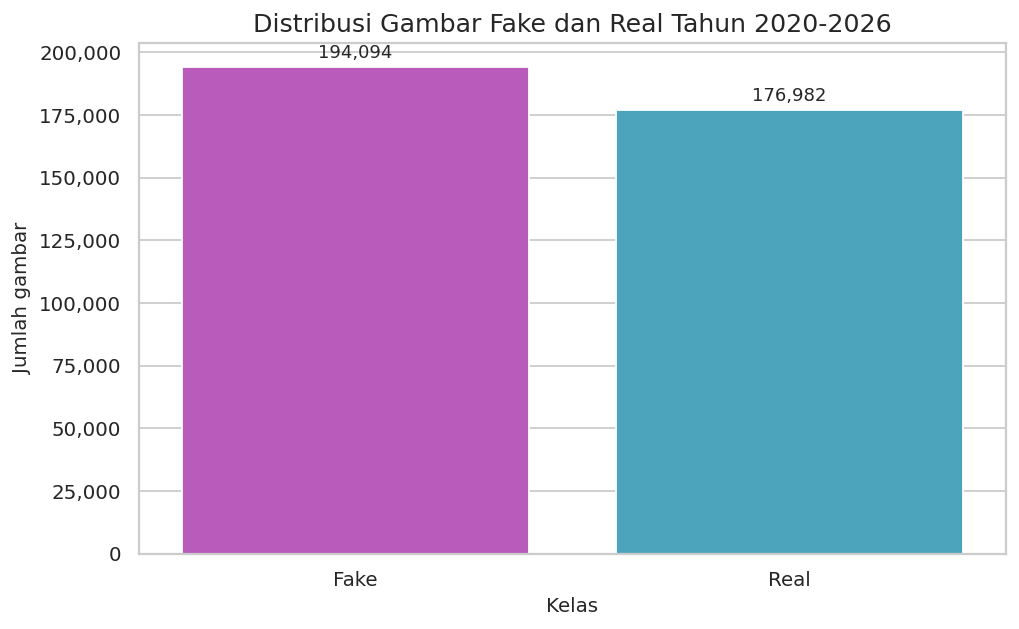

In [14]:
fig, ax = plt.subplots(figsize=(8, 5))
sns.barplot(
    data=class_distribution,
    x="class",
    y="count",
    hue="class",
    order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    legend=False,
    ax=ax,
)
for container in ax.containers:
    ax.bar_label(container, fmt="{:,.0f}", padding=3, fontsize=10)
ax.set_title(f"Distribusi Gambar Fake dan Real Tahun {DATASET_YEAR}")
ax.set_xlabel("Kelas")
ax.set_ylabel("Jumlah gambar")
ax.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")
save_figure("01_class_distribution_bar_chart.png")
plt.show()


Bar chart memvisualisasikan dua batang dengan tinggi yang tidak identik: batang kelas Fake lebih tinggi dari batang kelas Real. Perbedaan ini memberikan konfirmasi visual bahwa dataset tidak benar-benar seimbang, meskipun selisihnya tidak terlalu besar. Batang yang lebih tinggi pada kelas Fake mencerminkan dominasi kelas tersebut yang perlu dipertimbangkan dalam proses pelatihan model agar model tidak lebih mudah memprediksi kelas yang lebih banyak.

### 6.5 Bar Chart Distribusi Kelas per Split

---

Notebook menampilkan **grouped bar chart** yang memisahkan visualisasi distribusi kelas Fake dan Real berdasarkan split (Train, Validation, Test). Visualisasi ini memastikan bahwa keseimbangan kelas tidak hanya terjaga secara keseluruhan, tetapi juga **konsisten pada setiap subset data**.

---

Gambar tersimpan: 02_split_class_distribution_bar_chart.png


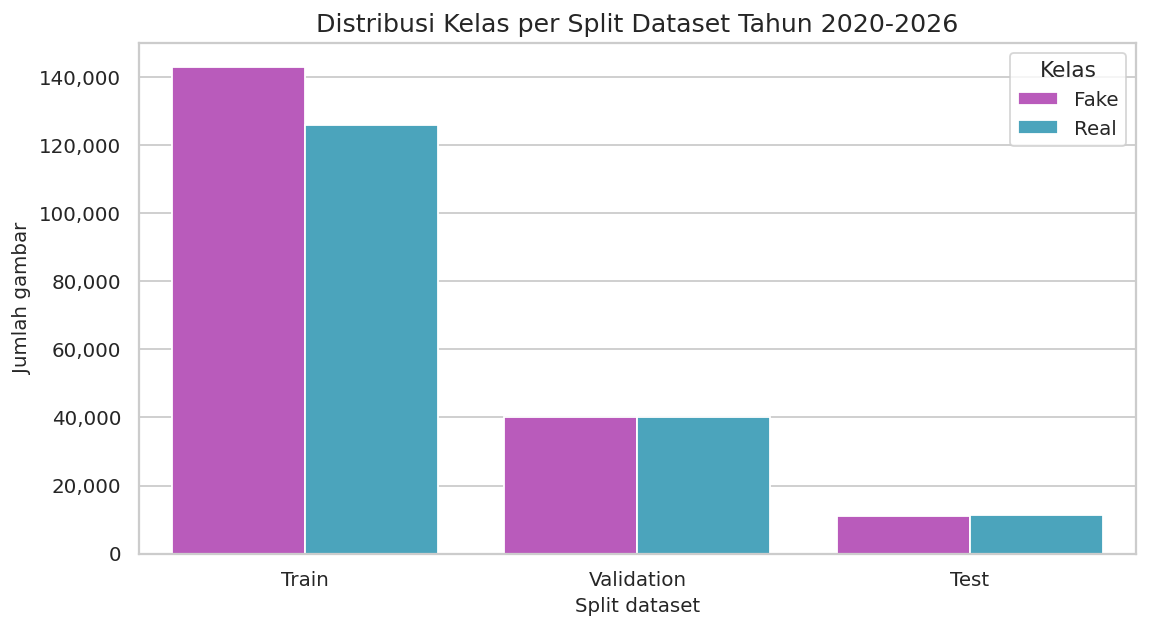

In [15]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.barplot(
    data=split_distribution,
    x="split",
    y="count",
    hue="class",
    hue_order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    ax=ax,
)
ax.set_title(f"Distribusi Kelas per Split Dataset Tahun {DATASET_YEAR}")
ax.set_xlabel("Split dataset")
ax.set_ylabel("Jumlah gambar")
ax.yaxis.set_major_formatter(lambda value, pos: f"{value:,.0f}")
ax.legend(title="Kelas")
save_figure("02_split_class_distribution_bar_chart.png")
plt.show()


*Grouped bar chart* menunjukkan perbedaan yang mencolok antar split. Pada split **Train**, batang Fake jauh lebih tinggi daripada batang Real, mencerminkan ketimpangan sebesar 6,38%. Sebaliknya, pada split **Validation** dan **Test**, pasangan batang Fake dan Real hampir sama tingginya, menunjukkan bahwa kedua split tersebut mendekati 50:50. Pola yang tidak konsisten ini penting untuk diperhatikan karena model yang dilatih pada data Train yang timpang berpotensi menghasilkan performa yang berbeda secara signifikan saat dievaluasi pada data Validation dan Test yang lebih seimbang.

---
### Insight dan Rekomendasi Business Question 1
 
**Kesimpulan**
 
Dataset tahun 2020-2026 terdiri dari 371.076 gambar dengan distribusi kelas yang **tidak sepenuhnya seimbang**: kelas Fake berjumlah 194.094 gambar (52,31%) dan kelas Real berjumlah 176.982 gambar (47,69%). Selisih absolut sebesar 17.112 gambar (4,61% dari total data) menghasilkan rasio kelas 1,0967:1 yang secara keseluruhan masih di bawah ambang 1,5:1, namun tidak dapat diabaikan begitu saja mengingat skala data yang sangat besar.
 
Yang lebih perlu diperhatikan adalah **konsentrasi ketimpangan pada split Train**: Fake 53,19% vs Real 46,81% dengan selisih lebih dari 17.000 gambar. Sementara Validation (50,03% vs 49,97%) dan Test (49,79% vs 50,21%) sudah mendekati seimbang sempurna. Kondisi ini berpotensi membuat model cenderung lebih sering memprediksi kelas Fake, terutama karena model belajar sepenuhnya dari split Train yang timpang. **Kesimpulannya: dataset memerlukan perhatian khusus pada ketimpangan split Train sebelum pelatihan model dimulai.**
 
**Rekomendasi Action Items**
 
* **Pertimbangkan penanganan ketimpangan pada split Train.** Meskipun rasio keseluruhan belum melampaui ambang 1,5:1, perbedaan lebih dari 17.000 gambar pada data pelatihan cukup signifikan untuk mempengaruhi kecenderungan prediksi model.
* **Terapkan *class weight* sebagai langkah pertama yang paling ringan.** Dengan memberikan bobot lebih tinggi pada kelas Real saat pelatihan, model dapat belajar memperhatikan kelas minoritas tanpa harus mengubah jumlah data.
* **Jika *class weight* tidak cukup, gunakan *random undersampling* pada kelas Fake di split Train.** Pendekatan ini menyeimbangkan jumlah data tanpa risiko overfitting yang sering terjadi pada metode *oversampling* seperti SMOTE.
* **Pantau metrik evaluasi yang tepat saat menilai model.** Gunakan F1-score atau AUC-ROC daripada sekadar akurasi, karena akurasi dapat terlihat tinggi meskipun model cenderung hanya memprediksi kelas Fake.
* **Pertahankan split Validation dan Test apa adanya.** Kedua split ini sudah mendekati seimbang sempurna dan cocok digunakan sebagai tolok ukur evaluasi yang adil dan tidak bias.
---

## 7. Business Question 2: Karakteristik Piksel Brightness dan Contrast

---

Analisis pada bagian ini menggunakan kombinasi **histogram**, **boxplot**, **statistik deskriptif**, dan **uji Mann-Whitney U** untuk membandingkan distribusi brightness dan contrast antara kelas Fake dan Real. Histogram dan boxplot membantu melihat bentuk sebaran dan nilai tengah secara visual. Uji **Mann-Whitney U** berfungsi untuk menguji apakah terdapat perbedaan signifikan antara 2 kelas. Metode ini lebih tepat digunakan dibandingkan uji-t karena distribusi nilai piksel di dunia nyata tidak selalu memenuhi asumsi parametrik (normalitas dan homogenitas varians). Namun karena jumlah sampel sangat besar, p-value saja tidak cukup sehingga **Cohen's d** dihitung sebagai *effect size* (besaran/ukuran efek) untuk menilai apakah perbedaan tersebut bermakna secara praktis, bukan sekadar signifikan secara statistik karena jumlah data yang banyak.

---

### 7.1 Histogram Distribusi Brightness

---

Notebook menampilkan **histogram dengan density** untuk memvisualisasikan sebaran nilai brightness pada kelas Fake dan Real dalam satu grafik. Mode **density** digunakan agar bentuk distribusi kedua kelas dapat dibandingkan secara adil meskipun jumlah sampelnya sangat besar.

---

Gambar tersimpan: 03_brightness_distribution_histogram.png


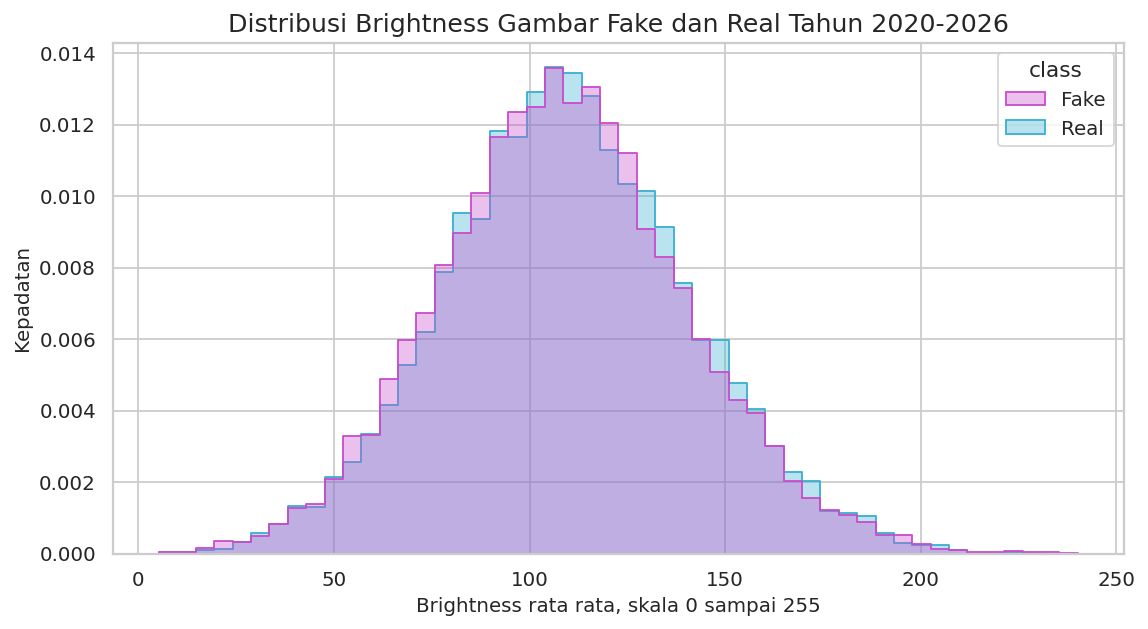

In [16]:
# ================================================================
# 7. BUSINESS QUESTION 2
# BRIGHTNESS DAN CONTRAST
# ================================================================

plot_df = pd.concat([
    safe_sample(clean_df[clean_df["class"] == "Fake"], PLOT_SAMPLE_SIZE),
    safe_sample(clean_df[clean_df["class"] == "Real"], PLOT_SAMPLE_SIZE),
]).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=plot_df,
    x="brightness_mean",
    hue="class",
    hue_order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
    ax=ax,
)
ax.set_title(f"Distribusi Brightness Gambar Fake dan Real Tahun {DATASET_YEAR}")
ax.set_xlabel("Brightness rata rata, skala 0 sampai 255")
ax.set_ylabel("Kepadatan")
save_figure("03_brightness_distribution_histogram.png")
plt.show()


Histogram brightness menunjukkan kurva distribusi kelas Fake dan Real yang sangat banyak bertumpang tindih, dengan kedua kurva berpuncak di rentang nilai yang hampir sama (sekitar 80–130). Kurva kelas Real terlihat sedikit bergeser ke kanan, mencerminkan nilai brightness yang secara rata-rata lebih tinggi dibandingkan kelas Fake. Namun tumpang tindih yang besar ini mengindikasikan bahwa fitur brightness saja tidak cukup kuat sebagai fitur tunggal untuk membedakan gambar Fake dan Real.

### 7.2 Histogram Distribusi Contrast

---

Notebook menampilkan histogram untuk memvisualisasikan sebaran nilai **contrast** pada kelas Fake dan Real. Analisis ini dilakukan untuk melihat apakah **variasi gelap-terang** gambar pada kedua kelas memiliki pola distribusi yang berbeda.

---

Gambar tersimpan: 04_contrast_distribution_histogram.png


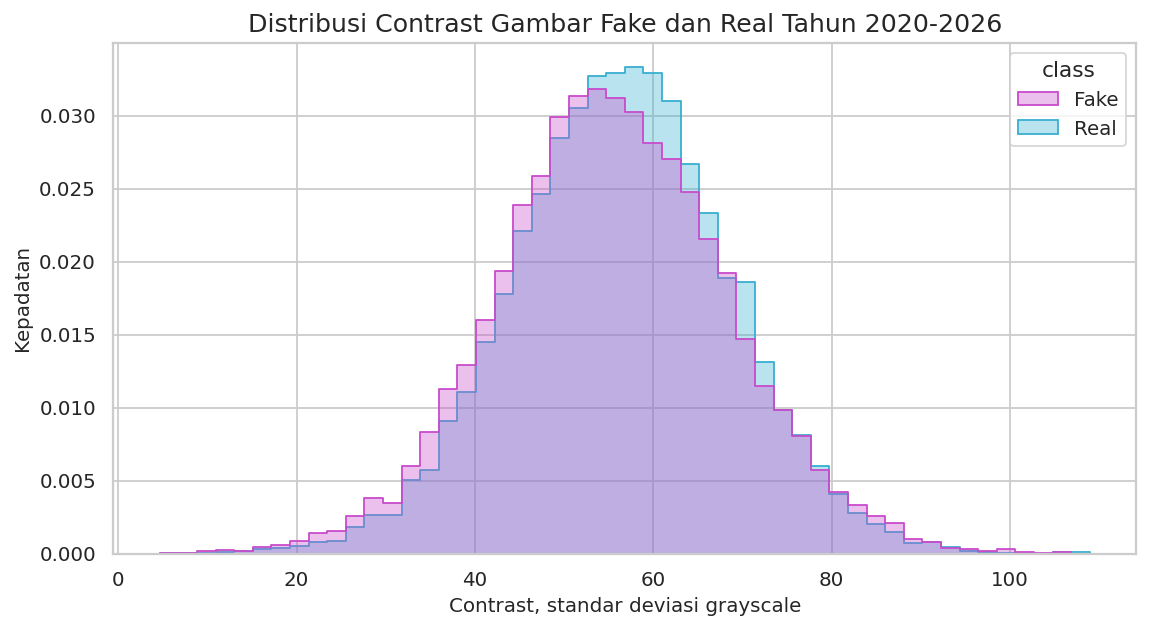

In [17]:
fig, ax = plt.subplots(figsize=(9, 5))
sns.histplot(
    data=plot_df,
    x="contrast_std",
    hue="class",
    hue_order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    bins=50,
    stat="density",
    common_norm=False,
    element="step",
    alpha=0.35,
    ax=ax,
)
ax.set_title(f"Distribusi Contrast Gambar Fake dan Real Tahun {DATASET_YEAR}")
ax.set_xlabel("Contrast, standar deviasi grayscale")
ax.set_ylabel("Kepadatan")
save_figure("04_contrast_distribution_histogram.png")
plt.show()


Histogram contrast menampilkan distribusi Fake dan Real yang hampir sepenuhnya berhimpit, dengan puncak distribusi kedua kelas berada pada rentang nilai yang sangat mirip (50–60). Meskipun kurva kelas Real sedikit bergeser ke kanan serupa dengan pola brightness, tumpang tindihnya sangat besar sehingga contrast pun tidak dapat berdiri sendiri sebagai fitur pembeda yang andal.

### 7.3 Boxplot Brightness per Kelas

---

Notebook menampilkan **boxplot** untuk memvisualisasikan **median**, **rentang antar-kuartil (IQR)**, dan potensi nilai ekstrem dari brightness pada masing-masing kelas. Boxplot memberikan ringkasan distribusi yang lebih kompak dibanding histogram dan memudahkan perbandingan posisi nilai tengah antar kelas.

---

Gambar tersimpan: 05_brightness_boxplot.png


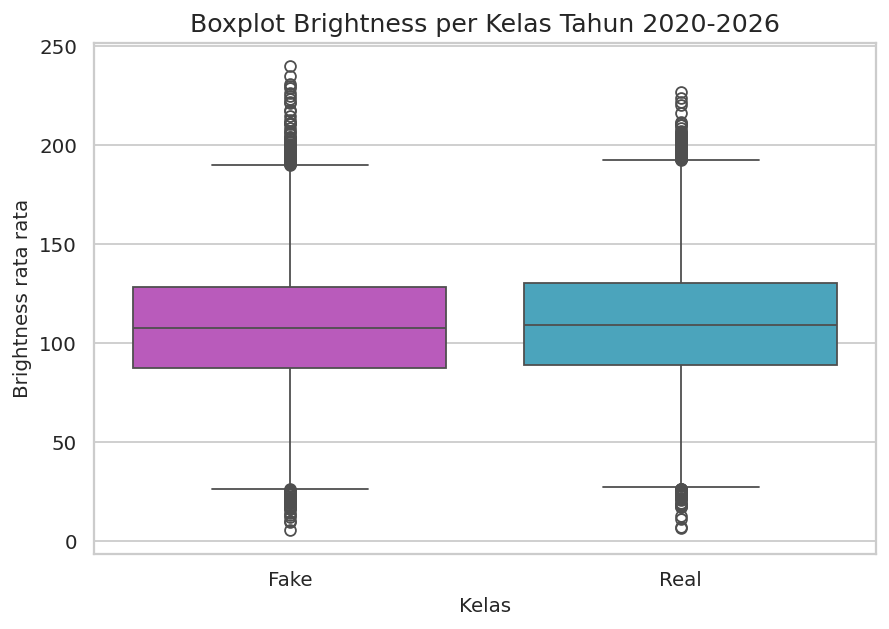

In [18]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=plot_df,
    x="class",
    y="brightness_mean",
    order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    ax=ax,
)
ax.set_title(f"Boxplot Brightness per Kelas Tahun {DATASET_YEAR}")
ax.set_xlabel("Kelas")
ax.set_ylabel("Brightness rata rata")
save_figure("05_brightness_boxplot.png")
plt.show()


Boxplot brightness menunjukkan bahwa median kelas Real sedikit lebih tinggi daripada median kelas Fake (sekitar 109 vs 108), dengan kotak boxplot kedua kelas yang hampir sepenuhnya tumpang tindih. Perbedaan posisi median ini konsisten dengan arah yang terlihat pada histogram, di mana kelas Real cenderung lebih cerah, namun perbedaannya secara visual tidak cukup signifikan untuk dijadikan dasar keputusan klasifikasi.

### 7.4 Boxplot Contrast per Kelas

---

Notebook menampilkan boxplot untuk membandingkan distribusi **contrast** antara kelas Fake dan Real. Pemeriksaan ini dilakukan untuk melihat apakah salah satu kelas memiliki **variasi gelap-terang** yang secara konsisten lebih besar atau lebih kecil.

---

Gambar tersimpan: 06_contrast_boxplot.png


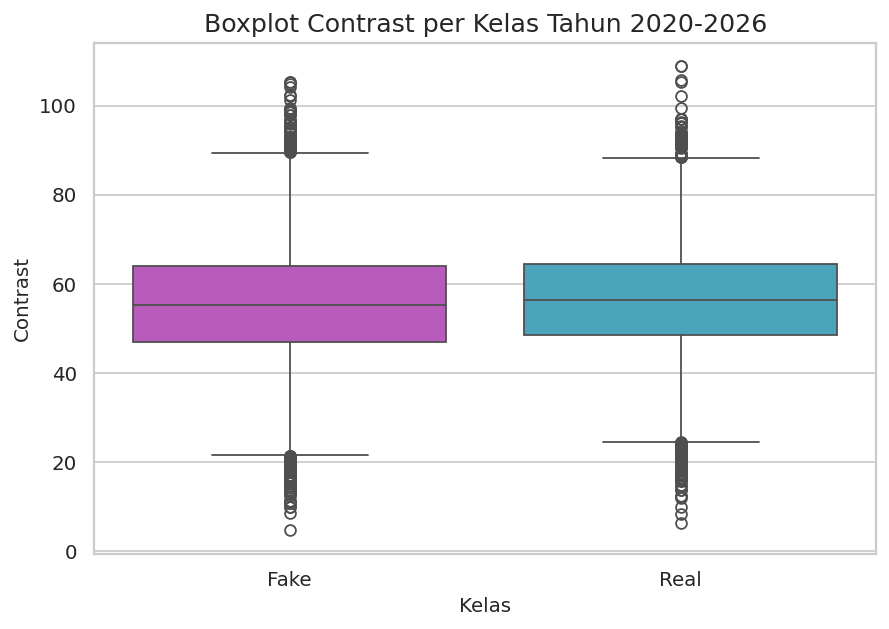

In [19]:
fig, ax = plt.subplots(figsize=(7, 5))
sns.boxplot(
    data=plot_df,
    x="class",
    y="contrast_std",
    order=CLASS_ORDER,
    palette=DEEPSHIELD_PALETTE,
    ax=ax,
)
ax.set_title(f"Boxplot Contrast per Kelas Tahun {DATASET_YEAR}")
ax.set_xlabel("Kelas")
ax.set_ylabel("Contrast")
save_figure("06_contrast_boxplot.png")
plt.show()


Boxplot contrast menunjukkan bahwa median kelas Real sedikit lebih tinggi dibandingkan kelas Fake (sekitar 56 vs 55), dengan IQR dan *whisker* yang hampir identik antara kedua kelas. Pola ini konsisten dengan temuan histogram dan memperkuat kesimpulan bahwa meskipun perbedaan contrast antar kelas dapat terdeteksi secara statistik, besarannya terlalu kecil untuk menjadi fitur pembeda yang bermakna secara praktis.

### 7.5 Statistik Deskriptif Brightness dan Contrast

---

Notebook menghitung **statistik deskriptif per kelas** yaitu mean, median, standar deviasi, minimum, dan maksimum untuk brightness dan contrast. Tabel ini menyajikan perbedaan antar kelas dalam **angka yang konkret** sehingga dapat dibaca secara langsung tanpa bergantung pada interpretasi visual grafik yang cenderung lebih intuitif.

---

In [20]:
pixel_statistics = clean_df.groupby("class", observed=False).agg(
    n_images=("file_path", "count"),
    brightness_mean=("brightness_mean", "mean"),
    brightness_median=("brightness_mean", "median"),
    brightness_std=("brightness_mean", "std"),
    brightness_min=("brightness_mean", "min"),
    brightness_max=("brightness_mean", "max"),
    contrast_mean=("contrast_std", "mean"),
    contrast_median=("contrast_std", "median"),
    contrast_std=("contrast_std", "std"),
    contrast_min=("contrast_std", "min"),
    contrast_max=("contrast_std", "max"),
).reset_index()
pixel_statistics.to_csv(TABLE_DIR / "pixel_brightness_contrast_statistics.csv", index=False)
print("Statistik brightness dan contrast per kelas:")
display(pixel_statistics)


Statistik brightness dan contrast per kelas:


,class,n_images,brightness_mean,brightness_median,brightness_std,brightness_min,brightness_max,contrast_mean,contrast_median,contrast_std,contrast_min,contrast_max
0,Fake,194094,108.6671,108.4163,31.5014,1.6954,248.5000,55.3888,55.2363,12.7407,4.5300,116.1788
1,Real,176982,109.9236,109.4843,31.5220,3.2439,245.2237,56.3793,56.3565,12.1791,4.6571,118.9240


Tabel statistik memperlihatkan bahwa rata-rata brightness kelas Real (≈109,92) lebih tinggi dibandingkan kelas Fake (≈108,67) pada skala 0–255, dengan selisih ≈1,26 poin. Untuk contrast, kelas Real juga memiliki rata-rata yang lebih tinggi (≈56,38 vs ≈55,39), dengan selisih ≈0,99. Arah perbedaan ini konsisten: kelas Real lebih terang dan lebih kontras dibandingkan kelas Fake. Namun selisihnya yang kecil secara numerik mempertegas temuan dari histogram dan boxplot bahwa perbedaan ini tidak bermakna secara praktis.

### 7.6 Uji Statistik Brightness dan Contrast

---

Notebook menjalankan **uji Mann-Whitney U** untuk menguji apakah distribusi brightness dan contrast berbeda secara statistik antara kelas Fake dan Real. Selain p-value, notebook juga menghitung **Cohen's d** sebagai *effect size*  yaitu indikator yang menunjukkan seberapa besar perbedaannya **secara praktis**, bukan hanya apakah perbedaan tersebut signifikan secara statistik.

---

In [21]:
pixel_tests = []
for metric in ["brightness_mean", "contrast_std"]:
    fake_values = clean_df.loc[clean_df["class"] == "Fake", metric]
    real_values = clean_df.loc[clean_df["class"] == "Real", metric]
    d_value = cohen_d(fake_values, real_values)
    test_result = mann_whitney_result(fake_values, real_values)
    pixel_tests.append({
        "metric": metric,
        "fake_mean": fake_values.mean(),
        "fake_median": fake_values.median(),
        "fake_std": fake_values.std(),
        "real_mean": real_values.mean(),
        "real_median": real_values.median(),
        "real_std": real_values.std(),
        "mean_difference_fake_minus_real": fake_values.mean() - real_values.mean(),
        "cohen_d": d_value,
        "effect_size_label": effect_size_label(d_value),
        "test_name": "Mann Whitney U" if SCIPY_AVAILABLE else "Tidak dijalankan",
        "p_value": test_result["p_value"],
        "significance": test_result["significance"],
    })

pixel_test_df = pd.DataFrame(pixel_tests)
pixel_test_df.to_csv(TABLE_DIR / "pixel_statistical_test.csv", index=False)
print("Hasil uji statistik brightness dan contrast:")
display(pixel_test_df)


Hasil uji statistik brightness dan contrast:


,metric,fake_mean,fake_median,fake_std,real_mean,real_median,real_std,mean_difference_fake_minus_real,cohen_d,effect_size_label,test_name,p_value,significance
0,brightness_mean,108.6671,108.4163,31.5014,109.9236,109.4843,31.5220,-1.2564,-0.0399,Sangat kecil,Mann Whitney U,0.0000,Signifikan pada p < 0.05
1,contrast_std,55.3888,55.2363,12.7407,56.3793,56.3565,12.1791,-0.9906,-0.0794,Sangat kecil,Mann Whitney U,0.0000,Signifikan pada p < 0.05


Uji Mann-Whitney U menunjukkan bahwa **brightness** berbeda secara statistik (p < 0,05) dengan Cohen's d sebesar -0,040 (kategori sangat kecil), dan **contrast** juga berbeda secara statistik (p < 0,05) dengan Cohen's d -0,079 (kategori sangat kecil). Kedua fitur kini signifikan secara statistik, namun *effect size* keduanya masih jauh dari ambang praktis. Ini merupakan konsekuensi dari ukuran sampel yang sangat besar: dengan 371.076 gambar, perbedaan sekecil apapun hampir selalu menghasilkan p-value yang sangat kecil sehingga *effect size* menjadi indikator yang jauh lebih relevan untuk menilai signifikansi praktis.

---
 
### Insight dan Rekomendasi Business Question 2
 
**Kesimpulan**
 
Kelas Real memiliki rata-rata brightness yang lebih tinggi (109,92) dibandingkan kelas Fake (108,67) pada skala 0–255, dengan selisih 1,26 poin. Untuk contrast, kelas Real juga lebih tinggi (56,38 vs 55,39) dengan selisih 0,99. Kedua perbedaan ini **signifikan secara statistik** (p < 0,05), namun Cohen's d untuk brightness hanya -0,040 dan untuk contrast hanya -0,079, keduanya masuk kategori efek yang **sangat kecil**. **Kesimpulannya: brightness dan contrast bukan indikator pembeda yang kuat antara gambar Fake dan Real secara praktis, meskipun gambar Real cenderung sedikit lebih terang dan lebih kontras.**
 
Perbedaan statistik yang muncul lebih disebabkan oleh ukuran sampel yang sangat besar (371.076 gambar), bukan karena ada pola nyata yang dapat diandalkan. Normalisasi gambar tetap direkomendasikan agar variasi kecil ini tidak menjadi bias teknis dalam pemodelan.
 
**Rekomendasi Action Items**
 
* **Terapkan normalisasi gambar sebelum melatih model.** Teknik seperti *rescaling* 0–1 atau z-score normalization memastikan variasi brightness dan contrast yang kecil tidak digunakan sebagai *shortcut* pembeda oleh model.
* **Augmentasi *color jittering* boleh ditambahkan sebagai variasi data**, bukan sebagai respons atas perbedaan distribusi yang kritis karena perbedaannya memang sangat kecil dan nilainya tidak cukup untuk diberdayakan secara mandiri.
* **Jangan mengandalkan brightness dan contrast sebagai fitur utama.** Keduanya dapat dimasukkan sebagai fitur pendukung, asalkan dikombinasikan dengan fitur yang lebih kuat dalam membedakan kelas Fake dan Real seperti tekstur dan struktur wajah.
---

## 8. Business Question 3: Distribusi Warna RGB

---

Analisis pada bagian ini menggunakan **KDE plot** (*Kernel Density Estimation*) untuk memvisualisasikan distribusi nilai intensitas warna pada channel **Red**, **Green**, dan **Blue** secara terpisah. KDE dipilih karena menghasilkan kurva distribusi yang lebih halus dibanding histogram, sehingga **pergeseran distribusi** antar kelas lebih mudah diamati. Selain visualisasi, notebook juga menghitung **mean**, **standar deviasi**, **selisih rata-rata**, dan **Cohen's d** per channel untuk menilai channel mana yang memberikan indikator pembeda paling kuat.

---

### 8.1 KDE Distribusi Channel RGB

---

Notebook menampilkan **KDE plot** secara terpisah untuk channel Red, Green, dan Blue. Setiap grafik menampilkan dua kurva (satu untuk Fake dan satu untuk Real) sehingga **pergeseran atau perbedaan bentuk distribusi** antar kelas dapat diamati secara visual untuk masing-masing channel warna.

---

Gambar tersimpan: 07_kde_rgb_red_channel.png


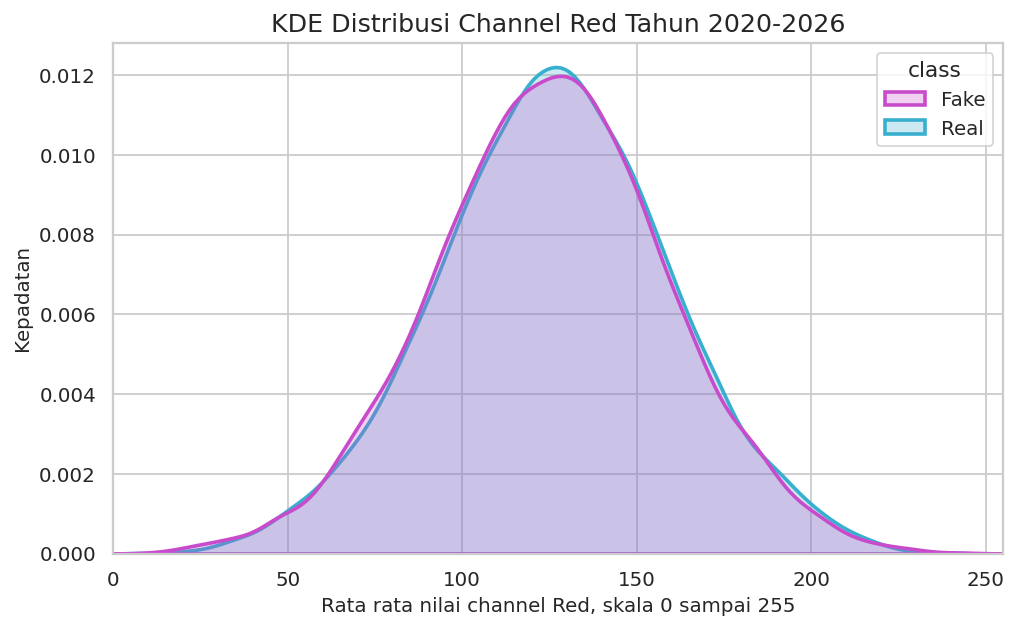

Gambar tersimpan: 07_kde_rgb_green_channel.png


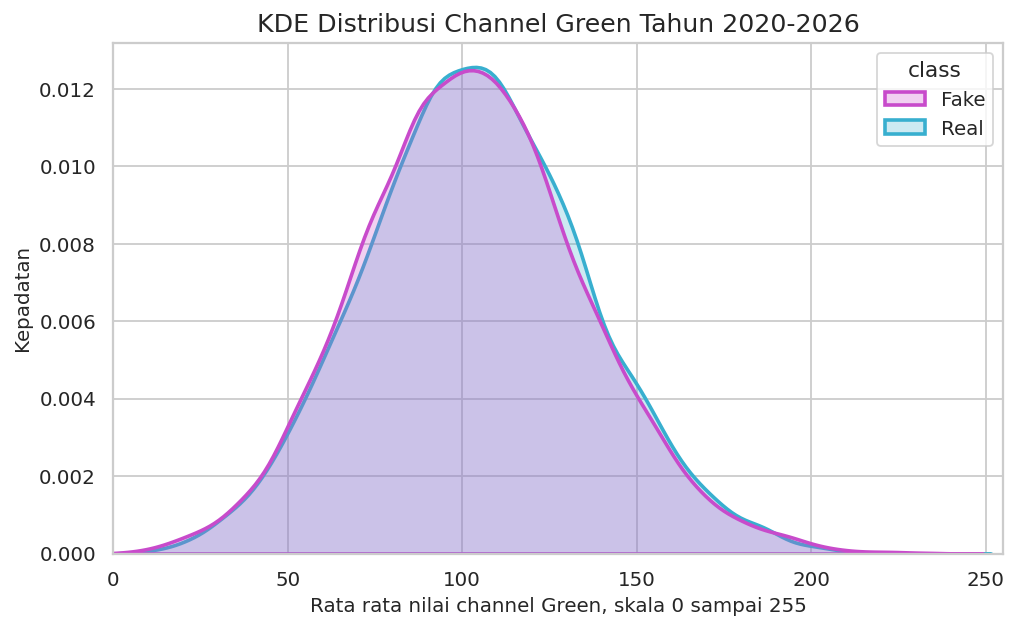

Gambar tersimpan: 07_kde_rgb_blue_channel.png


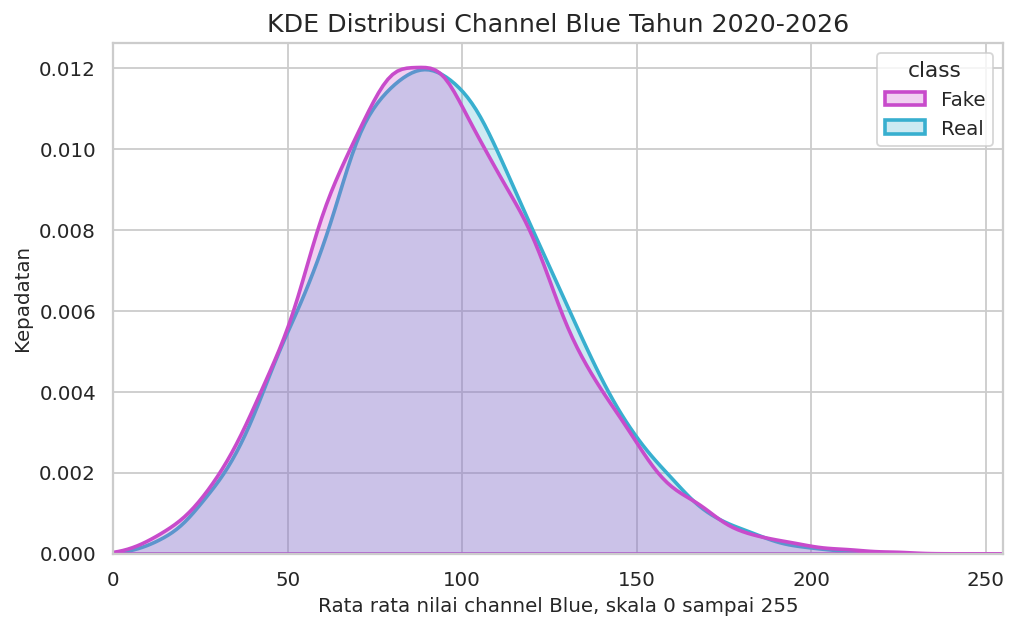

In [22]:
# ================================================================
# 8. BUSINESS QUESTION 3
# DISTRIBUSI WARNA RGB
# ================================================================

rgb_sample_df = pd.concat([
    safe_sample(clean_df[clean_df["class"] == "Fake"], RGB_SAMPLE_SIZE),
    safe_sample(clean_df[clean_df["class"] == "Real"], RGB_SAMPLE_SIZE),
]).reset_index(drop=True)

rgb_channels = {
    "r_mean": "Red",
    "g_mean": "Green",
    "b_mean": "Blue",
}

for column, channel_name in rgb_channels.items():
    fig, ax = plt.subplots(figsize=(8, 5))
    sns.kdeplot(
        data=rgb_sample_df,
        x=column,
        hue="class",
        hue_order=CLASS_ORDER,
        palette=DEEPSHIELD_PALETTE,
        fill=True,
        common_norm=False,
        alpha=0.25,
        linewidth=2,
        ax=ax,
    )
    ax.set_title(f"KDE Distribusi Channel {channel_name} Tahun {DATASET_YEAR}")
    ax.set_xlabel(f"Rata rata nilai channel {channel_name}, skala 0 sampai 255")
    ax.set_ylabel("Kepadatan")
    ax.set_xlim(0, 255)
    save_figure(f"07_kde_rgb_{channel_name.lower()}_channel.png")
    plt.show()


KDE plot pada ketiga channel menunjukkan kurva Fake dan Real yang banyak bertumpang tindih, namun pada setiap channel terlihat bahwa kurva kelas Real secara konsisten bergeser sedikit ke kanan dibandingkan kelas Fake. Artinya, gambar Real memiliki nilai intensitas rata-rata yang lebih tinggi pada ketiga channel sekaligus. Pergeseran ini paling mudah diamati pada channel Green yang menunjukkan jarak antar puncak kurva yang relatif lebih jauh, menjadikannya sinyal pembeda yang paling kuat di antara ketiga channel, meskipun tetap sangat kecil secara absolut.

### 8.2 Tabel Mean dan Standard Deviation Channel RGB

---

Notebook menghitung **mean** dan **standar deviasi** setiap channel warna (R, G, B) per kelas dalam bentuk tabel. Tabel ini memungkinkan pembacaan perbedaan warna secara **numerik dan terstruktur**, mendukung hasil temuan KDE plot yang bersifat visual.

---

In [23]:
rgb_statistics = clean_df.groupby("class", observed=False).agg(
    n_images=("file_path", "count"),
    r_mean=("r_mean", "mean"),
    r_std=("r_mean", "std"),
    g_mean=("g_mean", "mean"),
    g_std=("g_mean", "std"),
    b_mean=("b_mean", "mean"),
    b_std=("b_mean", "std"),
).reset_index()
rgb_statistics.to_csv(TABLE_DIR / "rgb_channel_statistics.csv", index=False)
print("Statistik channel RGB per kelas:")
display(rgb_statistics)


Statistik channel RGB per kelas:


,class,n_images,r_mean,r_std,g_mean,g_std,b_mean,b_std
0,Fake,194094,125.4611,33.4919,103.1852,32.1433,92.8470,33.4283
1,Real,176982,126.6206,33.6318,104.5224,32.0335,93.9419,33.2115


Tabel statistik RGB menunjukkan bahwa kelas Real secara konsisten memiliki rata-rata nilai intensitas yang lebih tinggi dibandingkan kelas Fake pada seluruh channel: Red Real (≈126,62) vs Fake (≈125,46) dengan selisih ≈1,16; Green Real (≈104,52) vs Fake (≈103,19) dengan selisih ≈1,34; Blue Real (≈93,94) vs Fake (≈92,85) dengan selisih ≈1,09. Channel **Green** memiliki selisih rata-rata terbesar secara absolut, menjadikannya channel dengan potensi pembeda tertinggi di antara ketiganya.

### 8.3 Selisih Rata Rata RGB dan Effect Size

---

Notebook menghitung **selisih rata-rata Fake minus Real**, **Cohen's d**, dan **p-value uji Mann-Whitney U** untuk setiap channel warna. Analisis ini dilakukan untuk mengidentifikasi channel mana yang memiliki **perbedaan paling signifikan** baik secara statistik maupun secara praktis antara gambar Fake dan Real.

---

In [24]:
rgb_difference_rows = []
for column, channel_name in rgb_channels.items():
    fake_values = clean_df.loc[clean_df["class"] == "Fake", column]
    real_values = clean_df.loc[clean_df["class"] == "Real", column]
    d_value = cohen_d(fake_values, real_values)
    test_result = mann_whitney_result(fake_values, real_values)
    rgb_difference_rows.append({
        "channel": channel_name,
        "fake_mean": fake_values.mean(),
        "fake_std": fake_values.std(),
        "real_mean": real_values.mean(),
        "real_std": real_values.std(),
        "mean_difference_fake_minus_real": fake_values.mean() - real_values.mean(),
        "cohen_d": d_value,
        "effect_size_label": effect_size_label(d_value),
        "test_name": "Mann Whitney U" if SCIPY_AVAILABLE else "Tidak dijalankan",
        "p_value": test_result["p_value"],
        "significance": test_result["significance"],
    })

rgb_difference_summary = pd.DataFrame(rgb_difference_rows)
rgb_difference_summary.to_csv(TABLE_DIR / "rgb_channel_difference_summary.csv", index=False)

strongest_rgb_channel = rgb_difference_summary.iloc[rgb_difference_summary["cohen_d"].abs().idxmax()]["channel"]
print("Ringkasan selisih channel RGB:")
display(rgb_difference_summary)

print(f"Channel dengan effect size terbesar: {strongest_rgb_channel}")


Ringkasan selisih channel RGB:


,channel,fake_mean,fake_std,real_mean,real_std,mean_difference_fake_minus_real,cohen_d,effect_size_label,test_name,p_value,significance
0,Red,125.4611,33.4919,126.6206,33.6318,-1.1595,-0.0346,Sangat kecil,Mann Whitney U,0.0000,Signifikan pada p < 0.05
1,Green,103.1852,32.1433,104.5224,32.0335,-1.3372,-0.0417,Sangat kecil,Mann Whitney U,0.0000,Signifikan pada p < 0.05
2,Blue,92.8470,33.4283,93.9419,33.2115,-1.0948,-0.0329,Sangat kecil,Mann Whitney U,0.0000,Signifikan pada p < 0.05


Channel dengan effect size terbesar: Green


Ringkasan *effect size* mengonfirmasi bahwa channel **Green** memiliki Cohen's d terbesar secara absolut (≈-0,042), diikuti Red (≈-0,035) dan Blue (≈-0,033). Nilai negatif pada ketiga channel menunjukkan bahwa seluruh channel memiliki arah yang sama: gambar Real lebih tinggi nilai intensitasnya daripada Fake. Ketiga channel signifikan secara statistik (p < 0,05), namun ketiganya masih masuk kategori "sangat kecil" berdasarkan konvensi Cohen. Meskipun Green menjadi channel paling informatif, perbedaannya tidak cukup besar untuk dijadikan satu-satunya dasar pembeda.

---
 
### Insight dan Rekomendasi Business Question 3
 
**Kesimpulan**
 
Ketiga channel warna menunjukkan pola yang **konsisten dan searah**: gambar Real memiliki nilai intensitas rata-rata yang lebih tinggi daripada Fake pada seluruh channel. Channel **Green** menunjukkan selisih rata-rata terbesar (Real 104,52 vs Fake 103,19, selisih 1,34) dan Cohen's d terbesar secara absolut (-0,042). Channel **Red** memiliki selisih 1,16 dengan Cohen's d -0,035, sementara channel **Blue** memiliki selisih 1,09 dengan Cohen's d -0,033. **Kesimpulannya: channel Green adalah channel warna yang paling informatif secara statistik, meskipun ketiga channel sama-sama berada dalam kategori efek yang sangat kecil.**
 
Konsistensi arah pada ketiga channel (Real selalu lebih tinggi dari Fake) mengindikasikan bahwa gambar *deepfake* secara sistematis menghasilkan intensitas warna yang sedikit lebih redup dibandingkan gambar asli. Pola ini mungkin merupakan artefak dari proses sintesis GAN yang kurang optimal dalam mereproduksi nilai intensitas warna tinggi. Arsitektur **Channel Attention** seperti SE-Net atau CBAM dapat dipertimbangkan untuk mengeksploitasi indikator pembeda kecil ini secara lebih optimal.
 
**Rekomendasi Action Items**
 
* **Prioritaskan channel Green sebagai fitur warna paling informatif.** Meskipun selisihnya kecil, Green secara konsisten memiliki *effect size* terbesar dan layak mendapat bobot lebih dalam arsitektur model yang mempertimbangkan informasi warna.
* **Pertimbangkan arsitektur Channel Attention (SE-Net atau CBAM).** Mekanisme ini memungkinkan model belajar secara otomatis memberi bobot lebih pada channel yang paling relevan, terutama Green, tanpa harus menghardcode bobot secara manual.
* **Gunakan informasi RGB sebagai fitur pendukung, bukan sebagai satu-satunya dasar deteksi.** Kombinasikan dengan fitur tekstur, tepi, dan struktur spasial wajah untuk hasil yang lebih andal.
* **Re-evaluasi distribusi RGB jika dataset diperbarui.** Pola artefak warna GAN dapat berubah seiring evolusi teknologi *deepfake*, sehingga temuan ini perlu divalidasi ulang pada data yang lebih baru.
---

## 9. Kesimpulan Utama dan Rekomendasi Action Items

---
Analisis EDA, visualisasi, dan *explanatory analysis* pada dataset DeepShield tahun 2020-2026 menghasilkan tiga kesimpulan utama, yaitu:
 
1. Distribusi kelas Fake dan Real **tidak sepenuhnya seimbang**. Dengan total 371.076 gambar, jumlah Fake adalah 194.094 gambar (52,31%) dan jumlah Real adalah 176.982 gambar (47,69%) dengan selisih 17.112 gambar. Ketimpangan ini terkonsentrasi di split Train (Fake 53,19% vs Real 46,81%), sementara Validation dan Test sudah mendekati 50:50. Kondisi ini memerlukan penanganan pada split Train agar model tidak bias memprediksi kelas mayoritas.
2. Karakteristik brightness dan contrast menunjukkan perbedaan yang sangat kecil dengan arah yang konsisten: gambar Real sedikit lebih terang (brightness Real 109,92 vs Fake 108,67) dan sedikit lebih kontras (contrast Real 56,38 vs Fake 55,39). Meskipun kedua perbedaan ini signifikan secara statistik (p < 0,05), Cohen's d masing-masing hanya -0,040 dan -0,079 sehingga efeknya masuk kategori sangat kecil. Brightness dan contrast dapat memberi gambaran awal, tetapi tidak cukup kuat untuk menjadi pembeda utama.
3. Distribusi RGB menunjukkan sinyal kecil yang **konsisten pada ketiga channel**: gambar Real selalu memiliki intensitas warna lebih tinggi daripada Fake. Channel Green memiliki *effect size* terbesar (Cohen's d -0,042), diikuti Red (-0,035) dan Blue (-0,033), namun ketiganya masih masuk kategori sangat kecil. Informasi warna dapat membantu sebagai sinyal pendukung, namun tidak dapat berdiri sendiri.
### Rekomendasi Action Items
 
1. Tangani ketimpangan kelas pada split Train sebelum pelatihan model dimulai, misalnya dengan menerapkan *class weight* atau *random undersampling* pada kelas Fake.
2. Pantau metrik evaluasi yang tepat seperti F1-score atau AUC-ROC, bukan hanya akurasi, karena dataset Train tidak seimbang sempurna.
3. Terapkan normalisasi gambar agar variasi brightness dan contrast yang kecil tidak terlalu memengaruhi hasil analisis lanjutan.
4. Lakukan proses *resize* atau *padding* pada gambar yang lebarnya tidak 256 piksel sebelum pemodelan, karena 7,53% dari total gambar memiliki dimensi lebar yang bervariasi.
5. Gunakan informasi RGB (khususnya channel Green) sebagai fitur pendukung, bukan sebagai satu-satunya dasar keputusan.
6. Saat mengembangkan analisis atau pemodelan lanjutan, gabungkan fitur piksel dengan pola visual lain seperti tekstur dan struktur wajah.
7. Tetap uji hasil pada data baru karena dataset ini berasal dari tahun 2020-2026 dan teknologi *deepfake* terus berkembang sehingga pola artefak warna dapat berubah.
---

## 10. Export Output untuk Dashboard dan Dokumentasi

---

Pada tahap terakhir, notebook **mengekspor seluruh tabel ringkasan dan visualisasi** ke folder output secara terstruktur. Proses ini memastikan hasil analisis dapat **digunakan kembali** untuk kebutuhan lainnya seperti kebutuhan dashboard Streamlit, pemodelan deep learning, maupun  laporan tanpa perlu menjalankan ulang proses komputasi dari awal. File yang tersimpan mencakup **distribusi kelas**, **distribusi per split**, **ringkasan keseimbangan data**, **statistik brightness dan contrast**, **hasil uji statistik**, **statistik RGB**, serta **ringkasan selisih *effect size* per channel warna**.

---

In [25]:
# ================================================================
# 9. EXPORT HASIL ANALISIS
# ================================================================

summary_files = {
    "image_inventory": TABLE_DIR / "image_inventory.csv",
    "image_features": TABLE_DIR / "image_features.csv",
    "class_distribution": TABLE_DIR / "class_distribution.csv",
    "split_class_distribution": TABLE_DIR / "split_class_distribution.csv",
    "balance_summary": TABLE_DIR / "balance_summary.csv",
    "pixel_brightness_contrast_statistics": TABLE_DIR / "pixel_brightness_contrast_statistics.csv",
    "pixel_statistical_test": TABLE_DIR / "pixel_statistical_test.csv",
    "rgb_channel_statistics": TABLE_DIR / "rgb_channel_statistics.csv",
    "rgb_channel_difference_summary": TABLE_DIR / "rgb_channel_difference_summary.csv",
}

print("Daftar file tabel yang tersedia:")
for name, path in summary_files.items():
    status = "ada" if path.exists() else "belum ada"
    print(f"{name}: {status} | {path}")

saved_figures = sorted(FIG_DIR.glob("*.png"))
print(f"Total visualisasi tersimpan: {len(saved_figures)}")
for figure_path in saved_figures:
    print(figure_path.name)

print("Export selesai.")
print(f"Folder output: {BASE_OUT.resolve()}")

Daftar file tabel yang tersedia:
image_inventory: ada | /kaggle/working/deepshield_eda_outputs/tables/image_inventory.csv
image_features: ada | /kaggle/working/deepshield_eda_outputs/tables/image_features.csv
class_distribution: ada | /kaggle/working/deepshield_eda_outputs/tables/class_distribution.csv
split_class_distribution: ada | /kaggle/working/deepshield_eda_outputs/tables/split_class_distribution.csv
balance_summary: ada | /kaggle/working/deepshield_eda_outputs/tables/balance_summary.csv
pixel_brightness_contrast_statistics: ada | /kaggle/working/deepshield_eda_outputs/tables/pixel_brightness_contrast_statistics.csv
pixel_statistical_test: ada | /kaggle/working/deepshield_eda_outputs/tables/pixel_statistical_test.csv
rgb_channel_statistics: ada | /kaggle/working/deepshield_eda_outputs/tables/rgb_channel_statistics.csv
rgb_channel_difference_summary: ada | /kaggle/working/deepshield_eda_outputs/tables/rgb_channel_difference_summary.csv
Total visualisasi tersimpan: 9
01_class_dist